# Assignment: Linear and logistic regression

## Objectives

The objectives of this assignment are:
1. to learn to use linear regression for predicting continuously varying target variables 
2. to learn to use logistic regression for binary classification
3. to learn to estimate the relative importance of input features

## Setup

In this assignment, use the Real Estate Valuation dataset that is available at [https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set). The data is collected from New Taipei City, Taiwan. 

## Task

The assignment consists of constructing *two* separate models for predicting the real estate prices in the dataset: one with linear and one with logistic regression.

1. **Linear regression model**: construct a linear regression model for predicting the continuous target variable "Y house price of unit area" in the dataset.

2. **Logistic regression model**: convert the target variable into a binary-valued one according to whether the original target value is above or below the average house price of unit area (within the training set samples), and construct a binary classifier for predicting its value with logistic regression.

Both models should be validated, with appropriate metrics presented and discussed. 

Remember to draw conclusions from your results and interpret your findings! Can you e.g. estimate which of the input variables has the most important role when predicting the house prices, and which ones are less important? Also, give some thought to whether the input data should be standardized before modeling or not. 

Prepare a Jupyter notebook containing a full account of the problem treatment. Construct your notebook to include sections for each of the six separate stages in the CRISP-DM model, with appropriate contents (include subsections for the two separate tasks in "Modeling" and "Evaluation").

## Deliverables

Submit a GitHub permalink that points to the Jupyter notebook as instructed in Oma. The submitted notebook must contain the problem analysis written in accordance with the CRISP-DM process model, complete with Markdown blocks and comments that clearly explain what has been done. 



## CRISP-DM
This notebook follows the CRISP-DM process model

CRISP-DM phases:

1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.


## 1. Business understanding

Goal of this project is to build machine learning models to predict real estate prices in **New Taipei City, Taiwan** using easily obtainable property and location characteristics.


The project involves making two separate models:

1. **Linear regression model** to predict the continuous target variable "Y house price unit area."

2. **Logistic regression model** to predict whether a property's price per unit area is above average (1) or below average (0) within the training set samples.


## 2. Data understanding

## 2.1 Importing the data
The dataset contains real estate valuations from Sindian Dist., New Taipei City, Taiwan, including Transaction Date, House Age, Distance to the nearest MRT station, number of convenience stores, location based on latitude and longitude and house prive of unit are.


In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)


# Data
features : DataFrame = real_estate_valuation.data.features
targets : DataFrame = real_estate_valuation.data.targets

# Metadata and variables info
metadata : DataFrame = real_estate_valuation.metadata
variables : DataFrame = real_estate_valuation.variables

# Dynamically extract target column name to prevent KeyError
target_col = targets.columns[-1]

print(f"Dataset Shape: {features.shape[0]} samples, {features.shape[1]} features")
#print(f"\nClass Distribution in '{target_col}' (10000 New Taiwan Dollar/Ping):")
# print(targets[target_col].value_counts())


# Check for missing values
print("\nMissing Values Check (Features):")
print(features.isnull().sum())
print("\nMissing Values Check (Targets):")
print(targets.isnull().sum())

# Summary statistics for features
print("\nFeatures Summary Statistics:")
display(features.describe().T[["mean", "std", "min", "50%", "max"]])

# Summary statistics for target variable
print(f"\nTarget Summary ('{target_col}'):")
display(targets.describe())

Dataset Shape: 414 samples, 6 features

Missing Values Check (Features):
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
dtype: int64

Missing Values Check (Targets):
Y house price of unit area    0
dtype: int64

Features Summary Statistics:


,mean,std,min,50%,max
X1 transaction date,2013.148971,0.281967,2012.66700,2013.16700,2013.58300
X2 house age,17.712560,11.392485,0.00000,16.10000,43.80000
X3 distance to the nearest MRT station,1083.885689,1262.109595,23.38284,492.23130,6488.02100
X4 number of convenience stores,4.094203,2.945562,0.00000,4.00000,10.00000
X5 latitude,24.969030,0.012410,24.93207,24.97110,25.01459
X6 longitude,121.533361,0.015347,121.47353,121.53863,121.56627



Target Summary ('Y house price of unit area'):


,Y house price of unit area
count,414.000000
mean,37.980193
std,13.606488
min,7.600000
25%,27.700000
50%,38.450000
75%,46.600000
max,117.500000


# 2.x Features & Metadata


In [14]:
# Example of data
features.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


In [15]:
# Metadata
metadata

{'uci_id': 477,
 'name': 'Real Estate Valuation',
 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set',
 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv',
 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ',
 'area': 'Business',
 'tasks': ['Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 414,
 'num_features': 6,
 'feature_types': ['Integer', 'Real'],
 'demographics': [],
 'target_col': ['Y house price of unit area'],
 'index_col': ['No'],
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2018,
 'last_updated': 'Mon Feb 26 2024',
 'dataset_doi': '10.24432/C5J30W',
 'creators': ['I-Cheng Yeh'],
 'intro_paper': {'ID': 373,
  'type': 'NATIVE',
  'title': 'Building real estate valuation models with comparative approach through case-based reason

### 2.6 Variables

The dataset should not have any missing variables.

In [16]:
# Variable information
variables

,name,role,type,demographic,description,units,missing_values
0,No,ID,Integer,None,NaN,NaN,no
1,X1 transaction date,Feature,Continuous,None,"for example, 2013.250=2013 March, 2013.500=201...",NaN,no
2,X2 house age,Feature,Continuous,None,NaN,year,no
3,X3 distance to the nearest MRT station,Feature,Continuous,None,NaN,meter,no
4,X4 number of convenience stores,Feature,Integer,None,number of convenience stores in the living cir...,integer,no
5,X5 latitude,Feature,Continuous,None,"geographic coordinate, latitude",degree,no
6,X6 longitude,Feature,Continuous,None,"geographic coordinate, longitude",degree,no
7,Y house price of unit area,Target,Continuous,None,"10000 New Taiwan Dollar/Ping, where Ping is a ...",10000 New Taiwan Dollar/Ping,no


### 2.7 Data Understanding: Summary

- The dataset contains 414 total instances.
- There are **6 features** (X1 to X6) and **1 target variable** (Y house price of unit area). Including the index/ID column ('No'), this makes a total of **8 variables** per entry.
- The ID column and the 'Number of convenience stores' (X4) are integers. The remaining variables (transaction date, house age, distance to MRT, latitude, longitude, and house price) are floats.
- There are no nulls in this dataset, meaning we do not need to drop rows or impute missing data.
- Because each feature has its own distinct units and scale (e.g., years for age, meters for distance, degrees for coordinates), applying feature scaling (like standardization or normalization) will be important to ensure models process the data evenly.


### 2.8 Data Understanding: Conclusions

## 3. Data Preparation


## 3.1 Separating training and testing data

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# confirm that no null entries actually exist
assert features.notna().all().all()
assert targets.notna().all().all()

# Hold-out validation split
features_train, features_test, target_train, target_test = train_test_split(
    features, 
    targets, 
    test_size=0.25, 
    random_state=69
)

# assert the list sizes
assert len(features_train) == len(target_train) and len(features_test) == len(target_test)

# Scale features
scaler = StandardScaler()

# Fit the scaler on training data only to learn its mean and variance
scaled_features_train = pd.DataFrame(scaler.fit_transform(features_train), columns=features.columns)

# Scale features_test using the exact same mean and variance learned from features_train
scaled_features_test = pd.DataFrame(scaler.transform(features_test), columns=features.columns)

print("Data Preparation Completed:")
print(f"Training set size: {features_train.shape[0]} samples.")
print(f"Testing set size: {features_test.shape[0]} samples.")

features_train.head(5)

Data Preparation Completed:
Training set size: 310 samples.
Testing set size: 104 samples.


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
133,2012.833,18.0,373.3937,8,24.98660,121.54082
302,2013.500,16.5,2288.0110,3,24.95885,121.51359
393,2013.000,16.9,967.4000,4,24.98872,121.53408
63,2013.583,2.6,533.4762,4,24.97445,121.54765
243,2013.417,32.8,204.1705,8,24.98236,121.53923


### 3.2 Interpretation

## 4. Modeling

### 4.1 Baseline model

#### 4.1.1 Linear

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(scaled_features_train, target_train)

# Extract the scalar intercept
b0 = model.intercept_.item()

# Extract the array of 6 coefficients and flatten it for printing
coefficients = model.coef_.ravel()

print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")

Intercept: 36.95
Coefficients:
1.08934
-3.00300
-5.67787
2.75896
3.32115
-0.32060


R² Score: 0.5716
RMSE: 9.0387
MAE: 6.7069


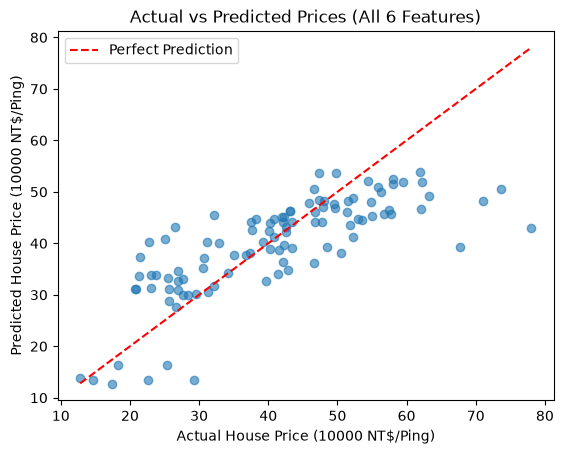

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predictions = model.predict(scaled_features_test)

# Calculate evaluation metrics comparing actual vs. predicted test prices

# Proportion of price variance 
r2 = r2_score(target_test, predictions)
# Avg prediction error. Penalizes large misses heavily
rmse = np.sqrt(mean_squared_error(target_test, predictions))
# Avg error in actual price units
mae = mean_absolute_error(target_test, predictions)

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")



plt.scatter(target_test, predictions, alpha=0.6)
min_val = target_test.min().item()
max_val = target_test.max().item()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Labels
plt.xlabel('Actual House Price (10000 NT$/Ping)')
plt.ylabel('Predicted House Price (10000 NT$/Ping)')
plt.title('Actual vs Predicted Prices (All 6 Features)')
plt.legend()
plt.show()


#### 4.1.2 Logistic, without stantardization

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Calculate the average price in the training set
average_price = target_train.mean().item()

# Create the binary target: 1 if > average, 0 if <= average
binary_target_train = (target_train > average_price).astype(int)
binary_target_test = (target_test > average_price).astype(int)

# Build and fit the model
"""
reg = LogisticRegression(solver='lbfgs')
reg.fit(features_train, binary_target_train.squeeze())
print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")
"""

log_reg = LogisticRegression(random_state=0,
                             C = 1.0,
                             fit_intercept=True,
                             ).fit(features_train, binary_target_train.squeeze())

train_acc = log_reg.score(features_train, binary_target_train)
test_acc = log_reg.score(features_test, binary_target_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}\n")

Train Accuracy: 0.8387
Test Accuracy: 0.8654


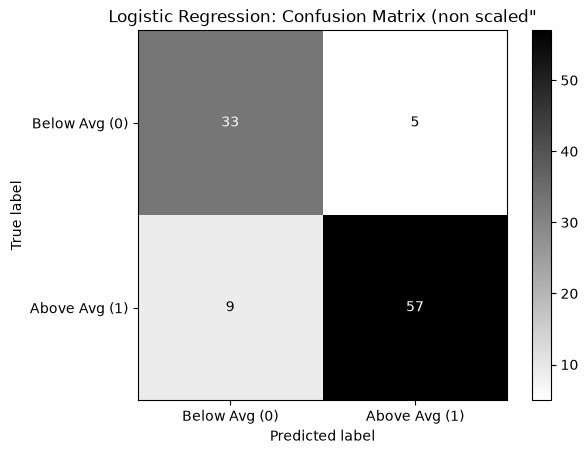

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate binary predictions
predictions_logistic = log_reg.predict(features_test)

# Create the confusion matrix
# compute confusion matrix agaisnt TEST labels
cm = confusion_matrix(binary_target_test, predictions_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Below Avg (0)', 'Above Avg (1)'])

disp.plot(cmap='binary')

plt.title('Logistic Regression: Confusion Matrix (non scaled"')
plt.show()


#### 4.1.2 Logistic, with stantardization

In [63]:
from sklearn.linear_model import LogisticRegression
import numpy as np

"""
# Calculate the average price in the training set
average_price = scaled_target_train.mean().item()

# Create the binary target: 1 if > average, 0 if <= average
binary_target_train = (scaled_target_train > average_price).astype(int)

# Build and fit the model 
reg = LogisticRegression(solver='lbfgs')
reg.fit(scaled_features_train, binary_target_train.squeeze())

print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")
"""

scaler = StandardScaler()

# Standardize features
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

log_reg1 = LogisticRegression(random_state=0,
                             C = 1.0,
                             fit_intercept=True,
                             ).fit(features_train_scaled, binary_target_train.squeeze())

train_acc1 = log_reg1.score(features_train_scaled, binary_target_train)
test_acc1 = log_reg1.score(features_test_scaled, binary_target_test)

print(f"Train Accuracy: {train_acc1:.4f}")
print(f"Test Accuracy: {test_acc1:.4f}\n")




Train Accuracy: 0.8548
Test Accuracy: 0.8750



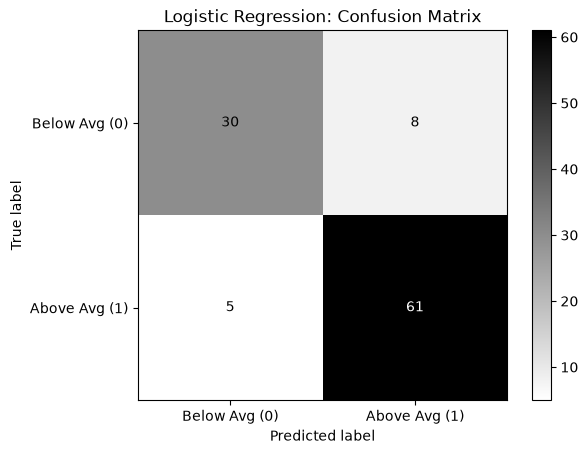

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate binary predictions
predictions_logistic = log_reg1.predict(features_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(binary_target_test, predictions_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Below Avg (0)', 'Above Avg (1)'])

disp.plot(cmap='binary')

plt.title('Logistic Regression: Confusion Matrix')
plt.show()


### 4.2 Optimizing 

### 4.3 Observations

## 5 Evaluation